# Title
# Multi-Subject Analysis of Hair Cycle Dynamics: A Sub-compartmentalized SIR-Based ODE Modeling.


# Contributors:<br/>
1. **Liladhar Paudel**
2. **Yoseph Asfaw**

# Objectives

### 1. Quantitative Analysis of Multi-Subject Follicle Dynamics
* **Baseline Trends**: Establish fundamental population trends for multiple subjects by analyzing mean follicle counts across **Anagen (A)**, **Catagen (C)**, and **Telogen (T)** phases, utilizing a simulated population of 1000 follicles.
* **Standardization**: Normalize raw data into **proportional distributions** to allow for consistent comparison of cycle dynamics across subjects with varying hair densities ($N$).


### 2. Implementation of Subcompartmentalized ODE Models
* **Advanced Framework**: Develop and implement a **Subcompartment ODE model** to move beyond standard linear transitions.
* **Stochastic Realism**: Capture the "non-exponential" nature of hair phase durations, ensuring follicles remain in a phase for a biologically realistic duration.
* **Optimization**: Identify subject-specific transition rates ($\alpha, \beta, \gamma$) using non-linear least squares regression.

### 3. Model Validation and Residual Diagnostics
* **Visual Verification**: Evaluate the accuracy of subcompartment fits using **comparative phase plots** and **multi-subject grid visualizations**.
* **Error Analysis**: Utilize **Residual Scatter/Line plots** and **Autocorrelation (ACF)** analysis to ensure the model captures transient dynamics without systematic bias.

### 4. Predictive Simulation of Biological Perturbations
* **Inhibition Modeling**: Simulates clinical suppression (e.g., hormonal hair loss) by analyzing the reduction of transition rates, such as **Alpha** (A→C) and **Gamma** (T→A).
* **Activation Modeling**: Simulates biochemical recovery by increasing (doubling) **Beta** (C→T) transition rate.
* **Clinical Benchmarking**: Uses the Anagen/Resting (A/R) Ratio to categorize outcomes and verify if they align with observed data from Subject 1 (Non-Alopecic) versus Subject 2 (Alopecic).


# Body of the Investigation

In [1]:
import base64
from IPython.display import HTML, display
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from tabulate import tabulate
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf


def draw_mermaid_centered(graph_code):
    graphbytes = graph_code.encode("ascii")
    base64_string = base64.b64encode(graphbytes).decode("ascii")
    url = "https://mermaid.ink/img/" + base64_string
    
    # Use the legacy <center> tag which Jupyter usually respects
    display(HTML(f'<center><img src="{url}"></center>'))

    
def print_styled(text, color="black"):
    # Centers, bolds, and colors the text in one line
    display(HTML(f'<div style="text-align:center; color:{color}; font-weight:bold; font-size:14px;">{text}</div>'))



my_graph = """
graph TD
A((A)) --> C((C))
C --> T((T))
T --> A
"""

draw_mermaid_centered(my_graph)
print_styled("Figure 1. A State Machine Representation of the Human Hair Follicular Transition")



# # --- Saving Mermaid graph ---
# import requests

# def save_mermaid_image(graph_code, filename):
#     graphbytes = graph_code.encode("ascii")
#     base64_string = base64.b64encode(graphbytes).decode("ascii")
#     url = "https://mermaid.ink/img/" + base64_string
    
#     response = requests.get(url)
#     if response.status_code == 200:
#         with open(filename, 'wb') as f:
#             f.write(response.content)
#         print(f"Saved Mermaid diagram to {filename}")

# # Call this before or after your Matplotlib logic
# F1 = "."
# save_mermaid_image(my_graph, f"{F1}/01a_hair_cycle_diagram_TD.png")


## Extended SIR model for the follicle life cycle

The graph above is a state machine representation of the life cycle of a follicle where:

- A &nbsp; Anagen is a growing state
- C &nbsp; Catagen is a transition stage
- T &nbsp; Talogen is a resting state

We propose SIR-like modeling:

$$
\frac{dA}{dt} = k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T - A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} ))
$$
$$
\frac{dC}{dt} = A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} )) - \gamma C
$$
$$
\frac{dT}{dt} =  \gamma C - k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T
$$
where:
- $k_{wake}$ is the maximum fraction of T that converts to A at a time
- $w_{nt}$ is a protein signaling awakening of follicles (converting from Talogen to Anagen)
- FGF5 is a protein that signals the transition from Anagen to Catagen. It is a growth inhibitor.
- DHT is a hormone that accelerates the FGF5 effect.
- $\gamma$ is the C to T conversion rate. It solely depends on the biological clock, not on hormones or proteins.

Treatments like minoxidal lowers the $k_{wnt}$ and Finosteride reduces DHT

Parameter variations:

- $K_{FGF5}$ and $K_{DHT}$ vary from person to person as they have strong genetic dependency
- DHT varies depending on age and health condition. More DHT at older ages.
- FGF5 and $W_{nt}$ can be assumed among people as they are produced at the same rate and quantity.
- $K_{wnt}$ also depends on genetics but can be assumed constant for people of similar age and health condition.


## Nonlinear regression to determine the parameters in the extended-SIR model.

There are no publicly available clinical datasets on hair loss or hair treatment that are directly relevant to this project. In particular, longitudinal measurements—such as follicle counts in the anagen (A) and telogen (T) phases, average follicle diameter, and related metrics—would be highly valuable. Such data could be used in a regression framework to estimate the parameters of an SIR-type model describing follicle state dynamics.

In the absence of suitable public datasets, we relied on Halloy et al. to generate synthetic data. Their work models the transition times between follicle states using log-normal distributions parameterized by experimentally derived values. Building on this framework, we conducted an agent-based simulation to produce longitudinal data, specifically tracking the number of follicles in the anagen (A), catagen (C), and telogen (T) states over time. We then fit the extended SIR model to the mean trajectories obtained by averaging across multiple simulation runs. 

The duration of each follicular phase is modeled using a log-normal distribution:

$$
f(x;\,\mu,\sigma)
= \frac{1}{x\,\sigma\sqrt{2\pi}}
\exp\!\left(
-\frac{(\log x - \mu)^2}{2\sigma^2}
\right),
\qquad x>0 \tag{1}
$$

The mean ($m$) and variance ($v$) of these durations are derived from experimental data. Using the moment-generating function, the parameters for the log-normal distribution are calculated as:

$$
\sigma _{\log }^2=\ln \! \left( 1+\frac{v}{m^2}\right) \tag{2a}
$$

$$
\mu _{\log }=\ln (m)-\frac{1}{2}\sigma _{\log }^2 \tag{2b}
$$



## I. Generate Synthetic Data

In [2]:
#---------------------------------------------------------
# 1. Log-normal duration sampler
#    (Phase durations drawn from empirical distributions)
#---------------------------------------------------------
def sample_duration(mu, sigma):
    """Sample a phase duration from the log-normal distribution in Eq. (1)."""
    return np.random.lognormal(mean=mu, sigma=sigma)


#---------------------------------------------------------
# 2. Probability of transition into pathological state M
#    (Slowly increasing probability as cycles accumulate)
#---------------------------------------------------------
def p_to_M(cycles):
    """Slowly increasing probability of transitioning to M."""
    return min(0.01 * (1 + 0.1 * cycles), 0.2)


#---------------------------------------------------------
# 3. Baseline follicle-cycle structure (A → C → T → A)
#---------------------------------------------------------
next_phase = {
    "A": "C",
    "C": "T",
    "T": "A"
}


#-----------------------------------------------------------
# 4. Phase-duration parameters for A, T, L, and optional M
#-----------------------------------------------------------
def convert_to_lognormal_params(mean, variance):
    sigma2_log = np.log(1 + variance / (mean**2))
    sigma_log = np.sqrt(sigma2_log)
    mu_log = np.log(mean) - 0.5 * sigma2_log
    return mu_log, sigma_log



#---------------------------------------------------------
# 5. Phase-transition rule
#    (Normal cycling or optional transition into M)
#---------------------------------------------------------
def choose_next_phase(phase, cycles, include_M=False):
    """
    Determine the next phase in the follicle cycle.
    If include_M=True, allow a slow-probability transition to M.
    """
    # If follicle is already in M, it stays there
    if phase == "M":
        return "M"

    # Normal cycle transitions
    next_phase_map = {"A": "C", "C": "T", "T": "A"}

    # If M transitions are disabled
    if not include_M:
        return next_phase_map[phase]

    # Otherwise include slow probability to M
    pM = p_to_M(cycles)

    if np.random.rand() < pM:
        return "M"
    else:
        return next_phase_map[phase]


#---------------------------------------------------------
# 6. Simulate a single follicle over T_end months
#---------------------------------------------------------
def simulate_follicle(T_end, include_M=False):
    
    rnd = np.random.rand()
        
    if rnd < 0.50:
        phase = 'A'

    elif rnd < 0.80:
        phase = 'T'

    else:
        phase = 'C'
        
    cycles = 0
    time_to_transition = sample_duration(*phase_params[phase])

    phases = []
    cycle_counts = []

    for t in range(T_end):

        # If already in M, stay in M
        if phase == "M":
            phases.append("M")
            cycle_counts.append(cycles)
            continue

        phases.append(phase)
        cycle_counts.append(cycles)

        time_to_transition -= 1

        if time_to_transition <= 0:

            # Use the new choice function
            phase = choose_next_phase(phase, cycles, include_M=include_M)

            # If moved to M, no new duration needed
            if phase == "M":
                continue

            # Otherwise sample new duration
            time_to_transition = sample_duration(*phase_params[phase])

            # Count cycles when entering A
            if phase == "A":
                cycles += 1

    return phases, cycle_counts



#---------------------------------------------------------
# 7. Simulate a population of independent follicles
#---------------------------------------------------------
def simulate_population(N_follicles, T_end, include_M=False, cooling=3):
    all_phases = []
    all_cycles = []
    for i in range(N_follicles):
        phases, cycles = simulate_follicle(T_end, include_M=include_M)
        all_phases.append(phases)
        all_cycles.append(cycles)
      
    # Convert both to numpy arrays for easier slicing/math
    return np.array(all_phases), np.array(all_cycles)


#---------------------------------------------------------
# 8. Population-level statistics at a given time t
#---------------------------------------------------------
def population_statistics(all_phases, all_cycles, t=None):
    """
    Compute counts for A, C, and T. 
    Include M only if it exists in the data.
    """
    # Slice the data based on whether a specific time t is provided
    if t is not None:
        target_data = all_phases[:, t]
        axis = None # Summing a 1D slice
    else:
        target_data = all_phases
        axis = 0    # Summing across follicles for each time step

    # Standard phases
    stats = {
        "A": np.sum(target_data == "A", axis=axis),
        "C": np.sum(target_data == "C", axis=axis),
        "T": np.sum(target_data == "T", axis=axis),
    }

    # Add M only if it is present in the data
    if np.any(target_data == "M"):
        stats["M"] = np.sum(target_data == "M", axis=axis)

    return stats



#---------------------------------------------------------
# 9. Paired simulations: with-M vs without-M transitions
#---------------------------------------------------------
def run_two_simulations(N, T_end):
    # With M transitions
    phases_M, cycles_M = simulate_population(N, T_end, include_M=True, cooling =3)

    # Without M transitions
    phases_noM, cycles_noM = simulate_population(N, T_end, include_M=False, cooling =3)

    return (phases_M, cycles_M), (phases_noM, cycles_noM)



#---------------------------------------------------------
# 10. Multi-Subject Population Simulation
#---------------------------------------------------------
def run_subject_populations(params, N=1000, T_end=200, n_simulation=25, include_M=False):
    global phase_params
    phase_params = params
    
    A, C, T, M = [], [], [], []
    
    for i in range(n_simulation):

        
        # Pass include_M into the simulation
        all_phases, all_cycles = simulate_population(N, T_end, include_M=include_M)
        data = population_statistics(all_phases, all_cycles)
        
        A.append(data['A'])
        C.append(data['C'])
        T.append(data['T'])
        if 'M' in data:
            M.append(data['M'])
            
    # Conditional return
    if include_M and len(M) > 0:
        return np.array(A), np.array(C), np.array(T), np.array(M)
    else:
        return np.array(A), np.array(C), np.array(T)



In [3]:
#----------------------------------------------------------
# 11. Generate follicle-cycle Data for baseline structure 
#  (A → C → T → A)
#----------------------------------------------------------   


mu_M = 3.0      # example mean duration of M
var_M = 2.0     # example variance of M


# Subject 1:
phase_params1 = {
    "A": convert_to_lognormal_params(16.91, 19.49**2),
    "C": convert_to_lognormal_params(1.79, 0.82**2),
    "T": convert_to_lognormal_params(5.23, 5.18**2),
}


# Subject 2:
phase_params2 = {
    "A": convert_to_lognormal_params(5.16, 4.50**2),
    "C": convert_to_lognormal_params(2.09, 1.06**2),
    "T": convert_to_lognormal_params(3.53, 5.43**2),
}


# Subject 3
phase_params3 = {
    "A": convert_to_lognormal_params(6.49, 10.16**2),
    "C": convert_to_lognormal_params(2.17, 1.11**2),
    "T": convert_to_lognormal_params(4.56, 9.57**2),
}



N_value = 1000
T_end_value=200
n_sim_value=25

# Running simulation for subjects 1 & 2 only:
A1, C1, T1 = run_subject_populations(phase_params1, N=N_value, T_end=T_end_value, n_simulation=n_sim_value)
A2, C2, T2 = run_subject_populations(phase_params2, N=N_value, T_end=T_end_value, n_simulation=n_sim_value)


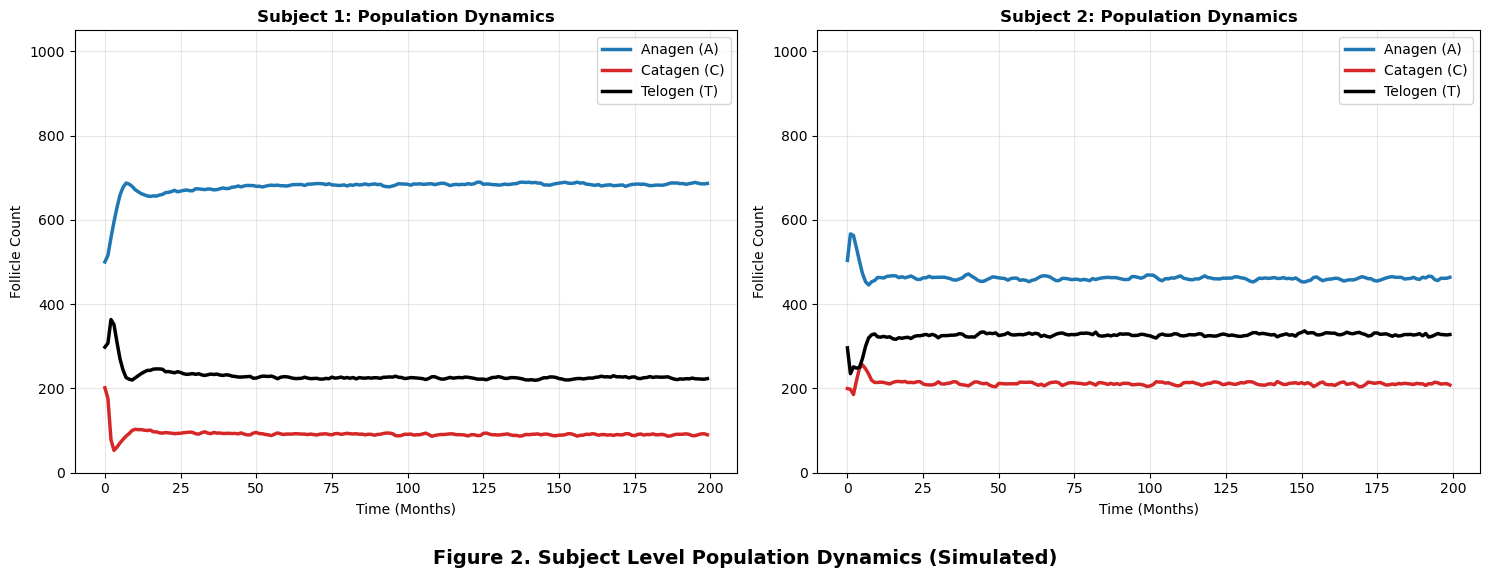

In [4]:
#-------------------------------------------------------
# Plotting follicle-cycle Data for baseline structure
#-------------------------------------------------------

colors = ['#1f77b4', '#d62728', '#000000'] # Blue (A), Red (C), Black (T)
labels = ['Anagen (A)', 'Catagen (C)', 'Telogen (T)']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_setup = [
    {"name": "Subject 1", "data": [A1, C1, T1], "ax": axes[0]},
    {"name": "Subject 2", "data": [A2, C2, T2], "ax": axes[1]}
]

for setup in plot_setup:
    ax = setup["ax"]
    # A, C, T are shape (25, 200)
    A_mean = np.mean(setup["data"][0], axis=0)
    C_mean = np.mean(setup["data"][1], axis=0)
    T_mean = np.mean(setup["data"][2], axis=0)
    
    means = [A_mean, C_mean, T_mean]
    
    for i in range(3):
        ax.plot(range(T_end_value), means[i], color=colors[i], label=labels[i], linewidth=2.5)

    # Formatting
    ax.set_title(f"{setup['name']}: Population Dynamics", fontweight='bold')
    ax.set_xlabel('Time (Months)')
    ax.set_ylabel('Follicle Count')
    ax.set_ylim(0, N_value + 50) # Set limit based on N
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)


fig.suptitle("Figure 2. Subject Level Population Dynamics (Simulated)", fontsize=14, fontweight='bold', y=0.02)
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()


In [5]:
#--------------------------------------------------------------------
# Generate follicle-cycle Data with Pathological state (M) included
#--------------------------------------------------------------------

# This code never runs
if False:
    # Define New Dictionaries for M-simulations
    phase_params1_M = phase_params1.copy()
    phase_params1_M["M"] = convert_to_lognormal_params(mu_M, var_M**2)
    
    phase_params2_M = phase_params2.copy()
    phase_params2_M["M"] = convert_to_lognormal_params(mu_M, var_M**2)
    
    phase_params3_M = phase_params3.copy()
    phase_params3_M["M"] = convert_to_lognormal_params(mu_M, var_M**2)
    
    # Run with 4 return variables
    A1_M, C1_M, T1_M, M1 = run_subject_populations(phase_params1_M, N=1000, include_M=True)
    A2_M, C2_M, T2_M, M2 = run_subject_populations(phase_params2_M, N=1000, include_M=True)
    A3_M, C3_M, T3_M, M3 = run_subject_populations(phase_params3_M, N=1000, include_M=True)


# II. Normalize and Apply Nonlinear Regression

Normalized ODEs:


$$
\frac{dA}{dt} = k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T - A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} ))
$$
$$
\frac{dC}{dt} = A(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n} .\frac{DHT^m}{DHT^m + K_{DHT}^m} )) - \gamma C
$$
$$
\frac{dT}{dt} =  \gamma C - k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})T
$$

Define:

- N = A + T + C
- a  = $\frac{A}{N}$
- c  = $\frac{C}{N}$
- r  = $\frac{T}{N}$

- $\alpha$ =  $k_{wake}(\frac{w_{nt}^n}{w_{nt}^n + k_{wnt}^n})$
- $\beta$ = $(\beta_{base} + \beta_{max}(\frac{FGF5^n}{FGF5^n + K_{FGF5}^n}.\frac{DHT^m}{DHT^m + K_{DHT}^m} )) $

The equation simplifies to:
$$
\frac{da}{dt} = \alpha r - \beta a
$$
$$
\frac{dc}{dt} = \beta a - \gamma c
$$
$$
\frac{dr}{dt} =  \gamma c - \alpha r
$$


### Equilibrium Analysis and System Dynamics

1. **Steady-State (The "Scalp Equilibrium")**

Setting the derivatives to zero ($\frac{da}{dt} = 0, \frac{dc}{dt} = 0, \frac{dr}{dt} = 0$) gives the long-term percentage of hair in each phase:

$$a^* = \frac{\alpha \gamma}{\alpha \beta + \beta \gamma + \alpha \gamma}$$

$$c^* = \frac{\alpha \beta}{\alpha \beta + \beta \gamma + \alpha \gamma}$$

$$r^* = \frac{\beta \gamma}{\alpha \beta + \beta \gamma + \alpha \gamma}$$


Where $a^*$, $b^*$, and $c^*$ are steady-state concentrations of Anagen (the growth or active phase), concentrations of Catagen (Transient or regression phase) and Telogen (Resting phase). Because $\gamma$ in the equation for $c^*$ is only in the donominator and is typically much larger than $\alpha$ or $\beta$, the value of $c^*$ remains very low, reflecting its nature as temporary bridge between growing and resting.

2. **The Alopecia Threshold**

In a healthy scalp, $\alpha \gg \beta$ (fast wake-up, slow exit). In an alopecic model, the value of $\beta$ (the DHT/FGF5 driver) increases significantly. We can calculate the **Anagen-to-Telogen ratio ($a/r$)**, a standard clinical metric, as:

$$\frac{a}{r} = \frac{\alpha}{\beta}$$

This shows that the ratio depends entirely on the balance between the **Wnt activator ($\alpha$) (wake-up rate)** and the **DHT/FGF5 inhibitor ($\beta$) (termination rate)**.

3. **Matrix Representation**

To solve this system in Python using linear algebra or to discuss the stability of the model in the report, the system can be written in the form $\mathbf{\dot{x}} = \mathbf{M}\mathbf{x}$:

$$\begin{bmatrix} \dot{a} \\ \dot{c} \\ \dot{r} \end{bmatrix} = \begin{bmatrix} -\beta & 0 & \alpha \\ \beta & -\gamma & 0 \\ 0 & \gamma & -\alpha \end{bmatrix} \begin{bmatrix} a \\ c \\ r \end{bmatrix}$$

4. **Convergence Behavior**

Because all non-zero eigenvalues of the matrix $M$ are negative, the system is **globally stable.** This means that no matter where a patient's hair cycle starts, it will always analytically converge to the steady state defined by the biochemical parameters $\alpha$, $\beta$, and $\gamma$.

In [6]:
# ---------------------------------------------------
# Normalizing Subject Follicle Data (baseline cycle)
# ---------------------------------------------------

# Assemble subject data together
subjects_data = [
    {"name": "Subject 1", "data": [A1, C1, T1]},
    {"name": "Subject 2", "data": [A2, C2, T2]},
    # Add Subject 3 here if you ran it: {"name": "Subject 3", "data": [A3, C3, T3]}
]


# Process and Normalize data for each subject
t_data = np.arange(T_end_value)
results = {}

for sub in subjects_data:
    # sub["data"] => [A, C, T] => along (axis=1) 
    # then transpose and divide by N to get proportions (0 to 1)
    avg_counts = np.mean(sub["data"], axis=1).T 
    norm_data = avg_counts / N_value  # N = N_value
    
    results[sub["name"]] = {
        "norm_data": norm_data,
        "x0": norm_data[0] # Initial proportions for solve_ivp
    }

# Check shape of normalized data
print(f"Shape for Subject 1: {results['Subject 1']['norm_data'].shape}")
print(f"Shape for Subject 2: {results['Subject 2']['norm_data'].shape}")

Shape for Subject 1: (200, 3)
Shape for Subject 2: (200, 3)


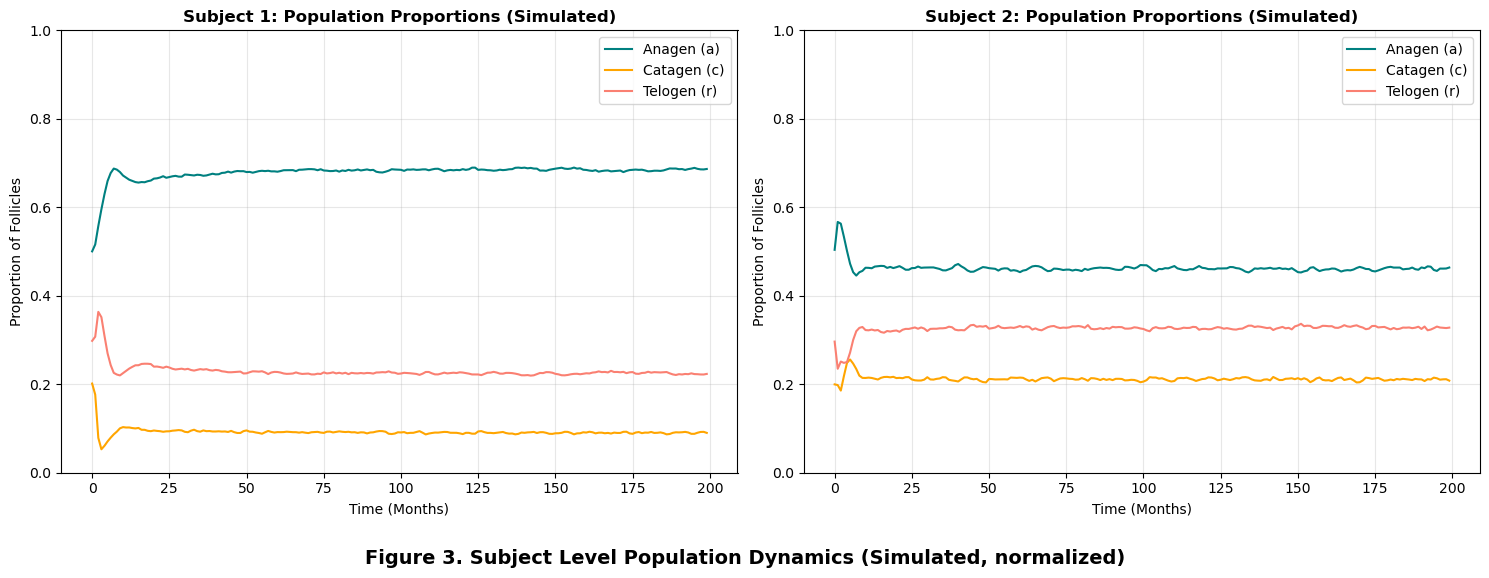

In [7]:
# -------------------------------------------------------------------
# Comparative Analysis of Subject Follicle Dynamics (baseline cycle)
# -------------------------------------------------------------------

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

labels = ['Anagen (a)', 'Catagen (c)', 'Telogen (r)']
colors = ['teal', 'orange', 'salmon']

# Plot Subject 1 (Left)
for i in range(3):
    axes[0].plot(results['Subject 1']['norm_data'][:, i], label=labels[i], color=colors[i])
axes[0].set_title('Subject 1: Population Proportions (Simulated)', fontweight='bold')
axes[0].set_xlabel('Time (Months)')
axes[0].set_ylabel('Proportion of Follicles')
axes[0].set_ylim(0, 1)  
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot Subject 2 (Right)
for i in range(3):
    axes[1].plot(results['Subject 2']['norm_data'][:, i], label=labels[i], color=colors[i])
axes[1].set_title('Subject 2: Population Proportions (Simulated)', fontweight='bold')
axes[1].set_xlabel('Time (Months)')
axes[1].set_ylabel('Proportion of Follicles')
axes[1].set_ylim(0, 1)  
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Figure 3. Subject Level Population Dynamics (Simulated, normalized)", fontsize=14,
             fontweight='bold', y=0.02)
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()


In [8]:
# Define variables to use in plottings below 
subjects = ["Subject 1", "Subject 2"]
phase_labels = ['Phase A', 'Phase C', 'Phase T']
labels_titles = ['Phase A', 'Phase C', 'Phase T']
labels = ['A', 'C', 'T']
labels_keys = ['A', 'C', 'T'] 

In [9]:
# ----------------------------------------------------------
# Non-linear Regression of Hair Cycle Data (baseline cycle)
# Parameter Estimation & ODE Integration
# ----------------------------------------------------------

def system(t, x, alpha, beta, gamma):
    a, c, r = x
    da = alpha * r - beta * a
    dc = beta * a - gamma * c
    dr = gamma * c - alpha * r
    return [da, dc, dr]


def simulate(theta, t_eval, x0):
    alpha, beta, gamma = theta
    sol = solve_ivp(
        lambda t, x: system(t, x, alpha, beta, gamma),
        (t_eval[0], t_eval[-1]),
        x0,
        t_eval=t_eval
    )
    return sol.y.T 


def residuals(theta, t_eval, data, x0):
    pred = simulate(theta, t_eval, x0)
    return (data - pred).ravel()


# Initial guess for [alpha, beta, gamma]
theta0 = [0.1, 0.1, 0.1]

for sub_name in subjects:
    # Retrieve the pre-processed normalized data and initial state
    norm_data = results[sub_name]['norm_data']
    x0 = results[sub_name]['x0']
    
    # Run the nonlinear regression to find best-fit parameters
    res = least_squares(
        residuals,                      # The function name
        theta0,                         # The first argument
        args=(t_data, norm_data, x0),   # The remaining arguments
        bounds=(0, np.inf),             # Ensures biological rates stay positive
        method='trf'                    # Trust Region Reflective (TRF) method of optimization
    )
    
    # Store full object, optimized parameters and the fitted simulations
    results[sub_name]['res_object'] = res 
    results[sub_name]['params'] = res.x
    results[sub_name]['Y_hat'] = simulate(res.x, t_data, x0)
    
    print(f"Finished fitting {sub_name}. Params: {res.x}")


Finished fitting Subject 1. Params: [0.25822223 0.08582106 0.63816571]
Finished fitting Subject 2. Params: [0.09523515 0.06764425 0.14712789]


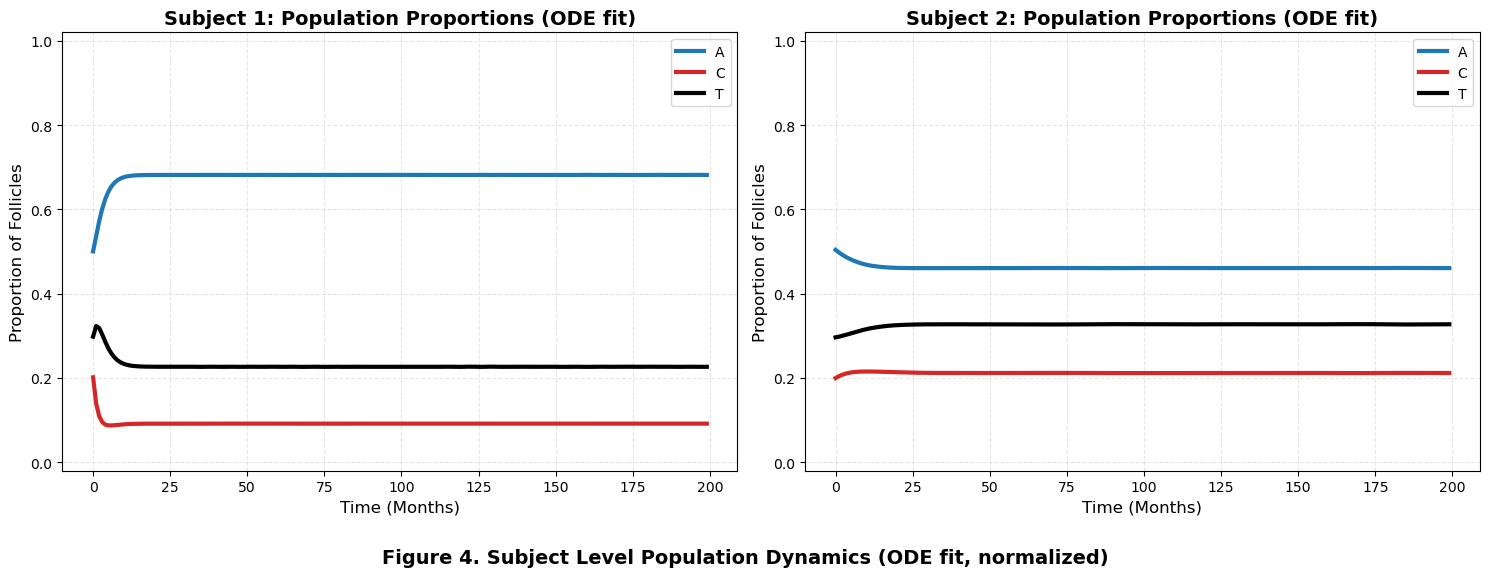

In [10]:
#----------------------------------------------------
# ODE fit plots for Hair Cycle Data (baseline cycle)
#----------------------------------------------------

colors = ['#1f77b4', '#d62728', '#000000']      # Blue (A/a), Red (C/c), Green (T/r)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, sub_name in enumerate(subjects):
    ax = axes[idx]
    
    # Extract the fitted ODE data only
    fitted = results[sub_name]['Y_hat']
    
    for i in range(3):
        # Plot the fitted ODE
        ax.plot(t_data, fitted[:, i], color=colors[i], label=labels[i], linewidth=3)

    # Formatting
    ax.set_title(f'{sub_name}: Population Proportions (ODE fit)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (Months)', fontsize=12)
    ax.set_ylabel('Proportion of Follicles', fontsize=12)
    
    # Consistent scale
    ax.set_ylim(-0.02, 1.02) 
    ax.legend(loc='upper right', frameon=True)
    ax.grid(True, alpha=0.3, linestyle='--')

fig.suptitle("Figure 4. Subject Level Population Dynamics (ODE fit, normalized)", fontsize=14,
             fontweight='bold', y=0.02)
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()


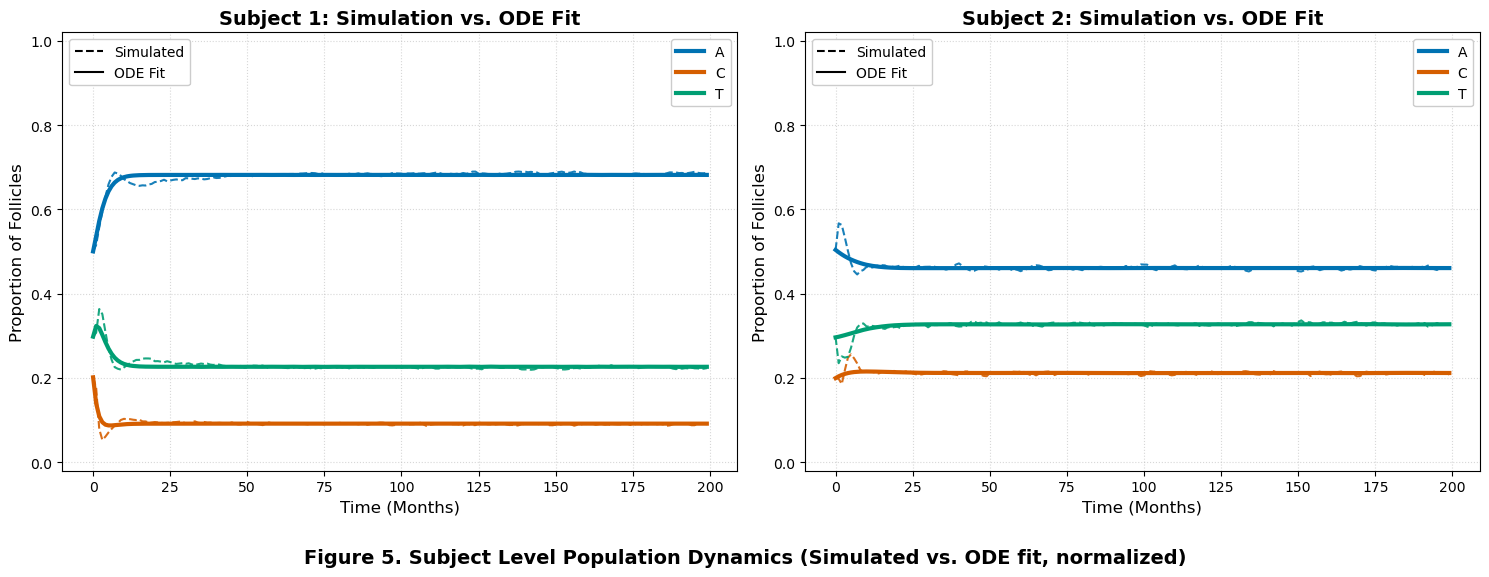

In [11]:
#------------------------------------------------------------------------------
# Hair Cycle Model: Parameter Estimation and Validation Plots (baseline cycle)
#------------------------------------------------------------------------------

colors = ['#0072B2', '#D55E00', '#009E73']  # Blue (A/a), Orange (C/c), Green (T/r)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, sub_name in enumerate(subjects):
    ax = axes[idx]
    
    orig = results[sub_name]['norm_data']  # Simulated data
    fitted = results[sub_name]['Y_hat']      # ODE Fit
    
    for i in range(3):
        # Simulated Data (Dashed Line)
        ax.plot(t_data, orig[:, i], color=colors[i], linestyle='--', linewidth=1.5, alpha=0.9)
        
        # ODE Fitted Results (Solid Line)
        ax.plot(t_data, fitted[:, i], color=colors[i], label=labels[i], linewidth=3)

    # Formatting
    ax.set_title(f'{sub_name}: Simulation vs. ODE Fit', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (Months)', fontsize=12)
    ax.set_ylabel('Proportion of Follicles', fontsize=12)
    ax.set_ylim(-0.02, 1.02) 
    ax.legend(loc='upper right', framealpha=1)
    ax.grid(True, linestyle=':', alpha=0.5)

    leg = ax.legend(loc='upper right', framealpha=1)
    
    style_lines = [Line2D([0], [0], color='black', linestyle='--', label='Simulated'),
                   Line2D([0], [0], color='black', linestyle='-', label='ODE Fit')]
    
    ax.add_artist(leg)
    ax.legend(handles=style_lines, loc='upper left', framealpha=1)



fig.suptitle("Figure 5. Subject Level Population Dynamics (Simulated vs. ODE fit, normalized)", fontsize=14,
             fontweight='bold', y=0.02)
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()


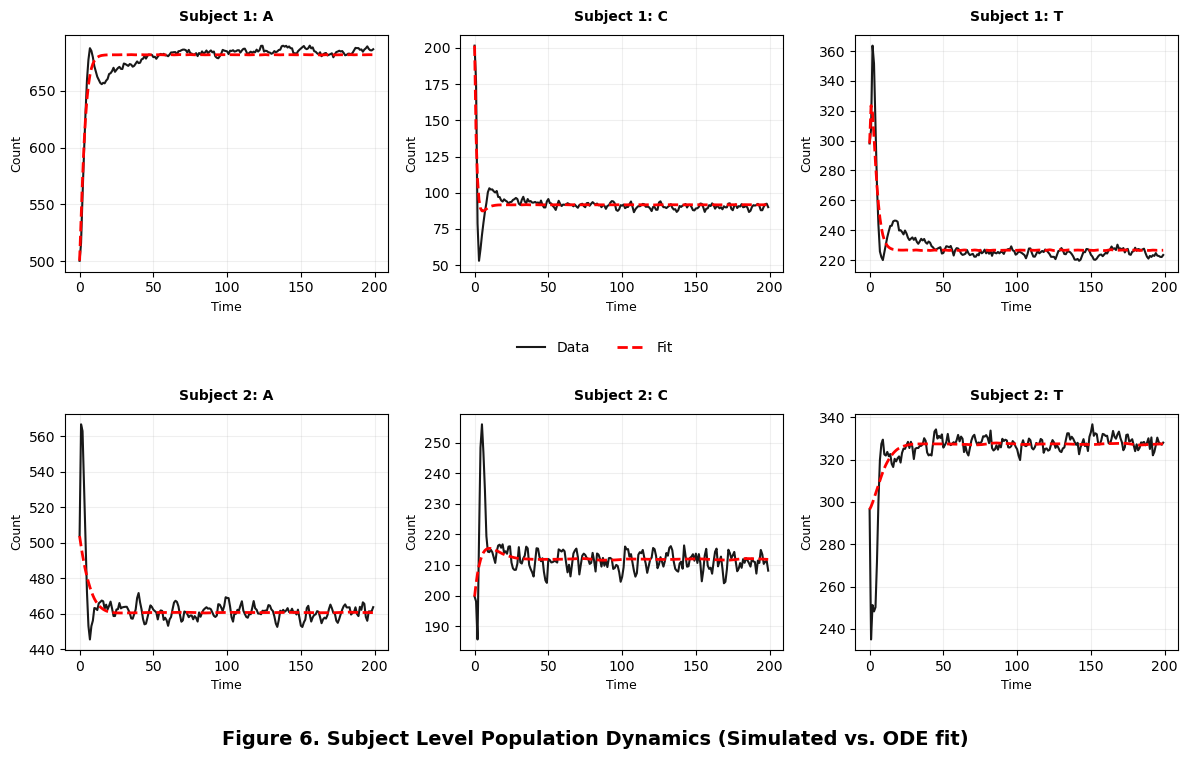

In [12]:
#---------------------------------------------------------------------------
# Fitting ODE Models to Simulated Hair Cycle Data (baseline cycle dynamics)
#---------------------------------------------------------------------------

fig, axs = plt.subplots(2, 3, figsize=(12, 7.5))

for row, sub_name in enumerate(subjects):
    orig = results[sub_name]['norm_data']
    fitted = results[sub_name]['Y_hat']
    
    for col in range(3):
        ax = axs[row, col]
        
        # Plotting
        l1, = ax.plot(t_data, orig[:, col] * N_value, '-', color='black', alpha=0.9, label='Data')
        l2, = ax.plot(t_data, fitted[:, col] * N_value, '--', color='red', linewidth=2, label='Fit')
        
        ax.set_title(f"{sub_name}: {labels[col]}", fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.grid(alpha=0.2)

# Placement of legend 
fig.legend(handles=[l1, l2], 
           loc='center', 
           bbox_to_anchor=(0.5, 0.53), 
           ncol=2, 
           frameon=True, 
           facecolor='white', 
           edgecolor='none')

# Tighten the layout
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(hspace=0.6) 
fig.suptitle("Figure 6. Subject Level Population Dynamics (Simulated vs. ODE fit)", fontsize=14,
             fontweight='bold', y=0.02)
plt.show()


In [13]:
#-----------------------------------------
# Compute RMSE (baseline cycle dynamics)
#-----------------------------------------

rmse_table = []

for sub_name in subjects:
    data = results[sub_name]['norm_data']
    pred = results[sub_name]['Y_hat']
    res = data - pred
    
    # Compute RMSE per phase and scale by N
    rmse_per_phase = np.sqrt(np.mean(res**2, axis=0)) * N_value
    
    rmse_table.append([sub_name, *rmse_per_phase])

# Display results
headers = ["Subject", "RMSE Phase A", "RMSE Phase C", "RMSE Phase T"]
print(f"\nTable 1: RMSE:")
print(tabulate(rmse_table, headers=headers, tablefmt="grid", floatfmt=".2f"))



Table 1: RMSE:
+-----------+----------------+----------------+----------------+
| Subject   |   RMSE Phase A |   RMSE Phase C |   RMSE Phase T |
+===========+================+================+================+
| Subject 1 |           7.53 |           5.88 |           7.63 |
+-----------+----------------+----------------+----------------+
| Subject 2 |           9.03 |           5.79 |           8.83 |
+-----------+----------------+----------------+----------------+


The model fits the data very well. The RMSE indicates that predictions are typically within an error bound of approximately 15 follicles for each follicle state. To further assess the appropriateness of the model, we analyze the residuals to examine any remaining structure or systematic patterns not captured by the model.

In [14]:
#----------------------------------------------------
# Compute Standard Errors (baseline cycle dynamics)
#----------------------------------------------------

uncertainty_table = []

for sub_name in subjects:
    res = results[sub_name]['res_object'] 
    
    rr = res.fun    # Residuals
    J = res.jac     # Jacobian matrix
    
    n = len(rr)     # Number of data points (200 * 3)
    p = len(res.x)  # Number of parameters (3)

    sigma2 = (rr @ rr) / (n - p) 
    
    cov = sigma2 * np.linalg.inv(J.T @ J) 
    se = np.sqrt(np.diag(cov))
    
    uncertainty_table.append([sub_name, se[0], se[1], se[2]])

# Display the results
headers = ["Subject", "SE (Alpha)", "SE (Beta)", "SE (Gamma)"]
print(f"\nTable 2: Parameter Uncertainty (Standard Errors):")
print(tabulate(uncertainty_table, headers=headers, tablefmt="grid", floatfmt=".6f"))



Table 2: Parameter Uncertainty (Standard Errors):
+-----------+--------------+-------------+--------------+
| Subject   |   SE (Alpha) |   SE (Beta) |   SE (Gamma) |
+===========+==============+=============+==============+
| Subject 1 |     0.000128 |    0.000128 |     0.000675 |
+-----------+--------------+-------------+--------------+
| Subject 2 |     0.006491 |    0.004583 |     0.009972 |
+-----------+--------------+-------------+--------------+


The standard error of parameters estimate is in the order of 0.01 which is acceptable.

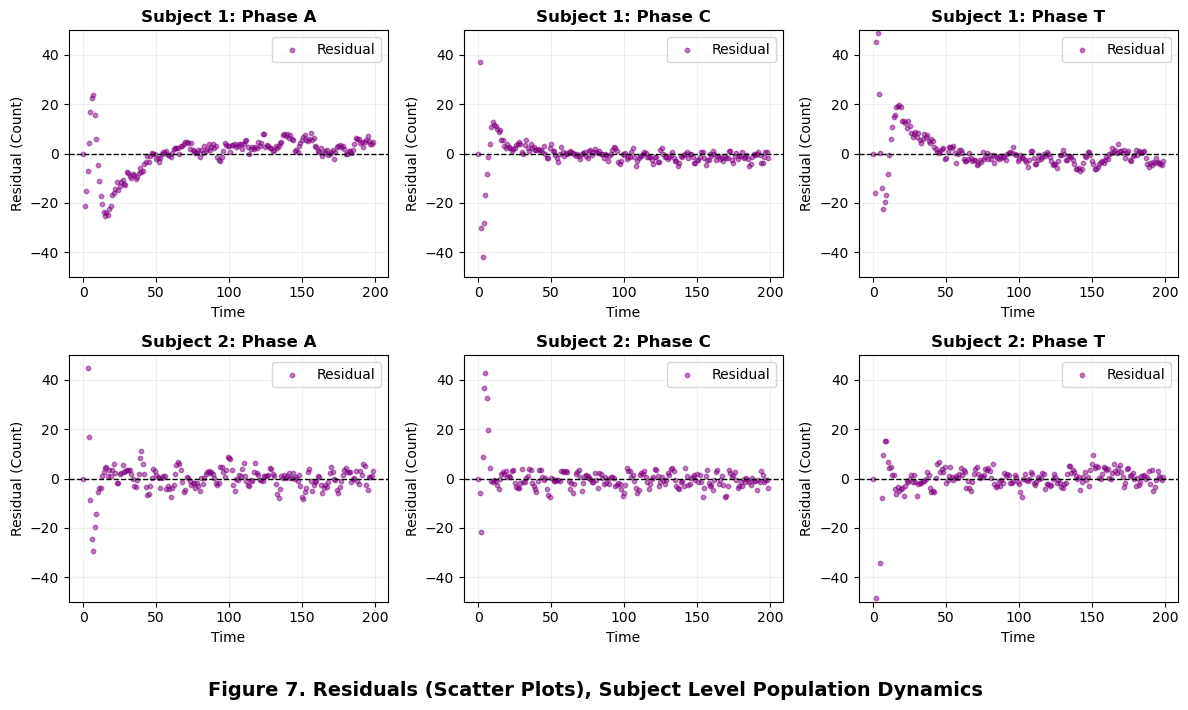

In [15]:
#-------------------------------------------------
# Residue scatter plots (baseline cycle dynamics)
#-------------------------------------------------

fig, axs = plt.subplots(2, 3, figsize=(12, 7))

for row, sub_name in enumerate(subjects):
    # Retrieve norm-data and ODE fit
    data = results[sub_name]['norm_data']
    pred = results[sub_name]['Y_hat']
    
    res = (data - pred) * N_value 
    
    for col in range(3):
        ax = axs[row, col]
        
        ax.scatter(t_data, res[:, col], s=10, alpha=0.5, color='purple', label='Residual')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        
        ax.set_title(f"{sub_name}: {phase_labels[col]}", fontweight='bold')
        ax.set_xlabel('Time')
        ax.set_ylabel('Residual (Count)')
        
        ax.set_ylim(-50, 50) 
        
        ax.grid(alpha=0.2)
        ax.legend(loc='upper right')


plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle("Figure 7. Residuals (Scatter Plots), Subject Level Population Dynamics", fontsize=14,
             fontweight='bold', y=0.02)
plt.show()

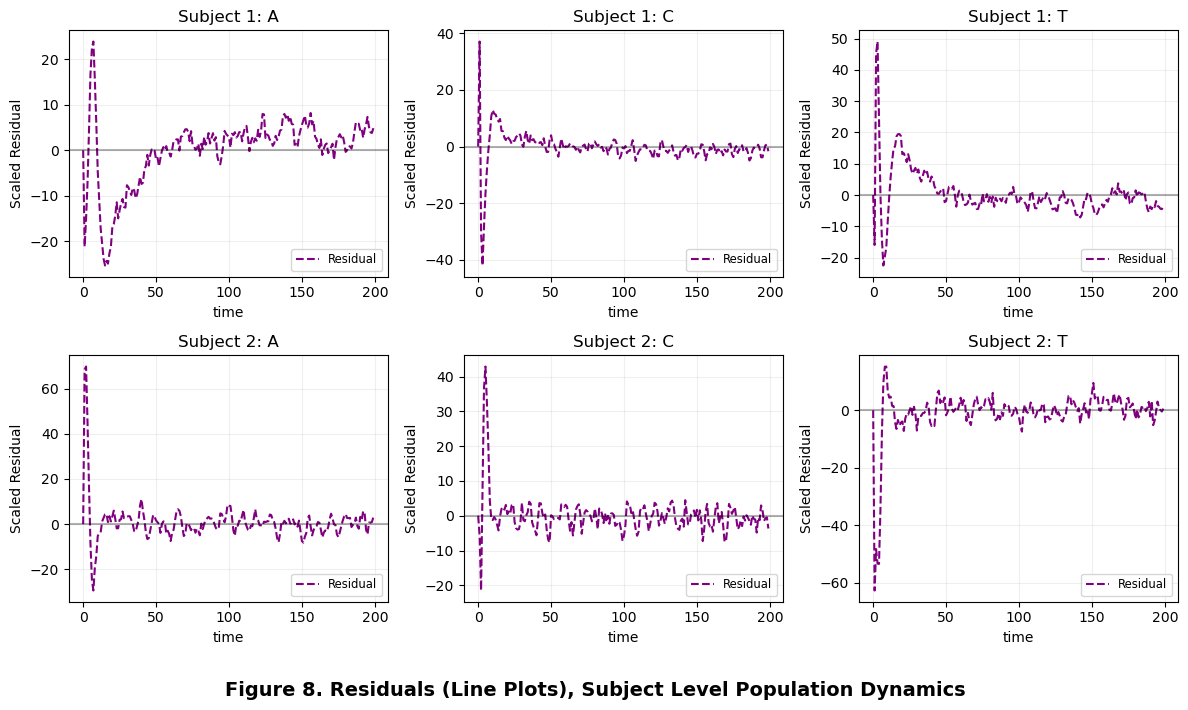

In [16]:
#-------------------------------------------------
# Residue Line Plots
#-------------------------------------------------

# 2 rows for subjects, 3 columns for phases
fig, axs = plt.subplots(2, 3, figsize=(12, 7))

for row, sub_name in enumerate(subjects):
    # 1. Retrieve the ORIGINAL residuals (not the subcomp ones)
    # Usually stored in 'res_object' from your first fitting
    rr = results[sub_name]['res_object'].fun
    
    # 2. Reshape to (Time, 3) 
    # Use len(t_data) or your T_end_value to match the original fit length
    res_matrix = rr.reshape((len(t_data), 3))
    
    for col in range(3):
        ax = axs[row, col]
        
        # 3. Plotting with your N_value scaling
        ax.plot(t_data, res_matrix[:, col] * N_value, '--', 
                linewidth=1.5, color='purple', label='Residual')
        
        # Zero line reference
        ax.axhline(0, color='black', linestyle='-', alpha=0.3)
        
        ax.set_title(f"{sub_name}: {labels[col]}")
        ax.set_xlabel('time')
        ax.set_ylabel('Scaled Residual')
        ax.legend(loc='lower right', fontsize='small')
        ax.grid(alpha=0.2)


plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle("Figure 8. Residuals (Line Plots), Subject Level Population Dynamics", fontsize=14,
             fontweight='bold', y=0.02)
plt.show()


In [17]:
#----------------------------------------------------------------------
# Perform Engle's ARCH test on the residuals (baseline cycle dynamics)
#----------------------------------------------------------------------

arch_results = []

for sub_name in ["Subject 1", "Subject 2"]:
    rr = results[sub_name]['res_object'].fun
    res_matrix = rr.reshape((200, 3))
    subject_row = [sub_name]
    
    for i in range(3):
        f_arch, p_arch = het_arch(res_matrix[:, i])[-2:]
        
        subject_row.append(f"{f_arch:.2f} / {p_arch:.2e}")
        
    arch_results.append(subject_row)

headers = ["Subject", "Phase A (F/p)", "Phase C (F/p)", "Phase T (F/p)"]
print(f"\nTable 3: Engle's ARCH test:")
print(tabulate(arch_results, headers=headers, tablefmt="grid"))



Table 3: Engle's ARCH test:
+-----------+--------------------+-------------------+-------------------+
| Subject   | Phase A (F/p)      | Phase C (F/p)     | Phase T (F/p)     |
+===========+====================+===================+===================+
| Subject 1 | 300.20 / 3.36e-106 | 167.55 / 2.65e-85 | 198.42 / 2.92e-91 |
+-----------+--------------------+-------------------+-------------------+
| Subject 2 | 7.54 / 5.56e-10    | 2.77 / 3.38e-03   | 2.82 / 2.86e-03   |
+-----------+--------------------+-------------------+-------------------+


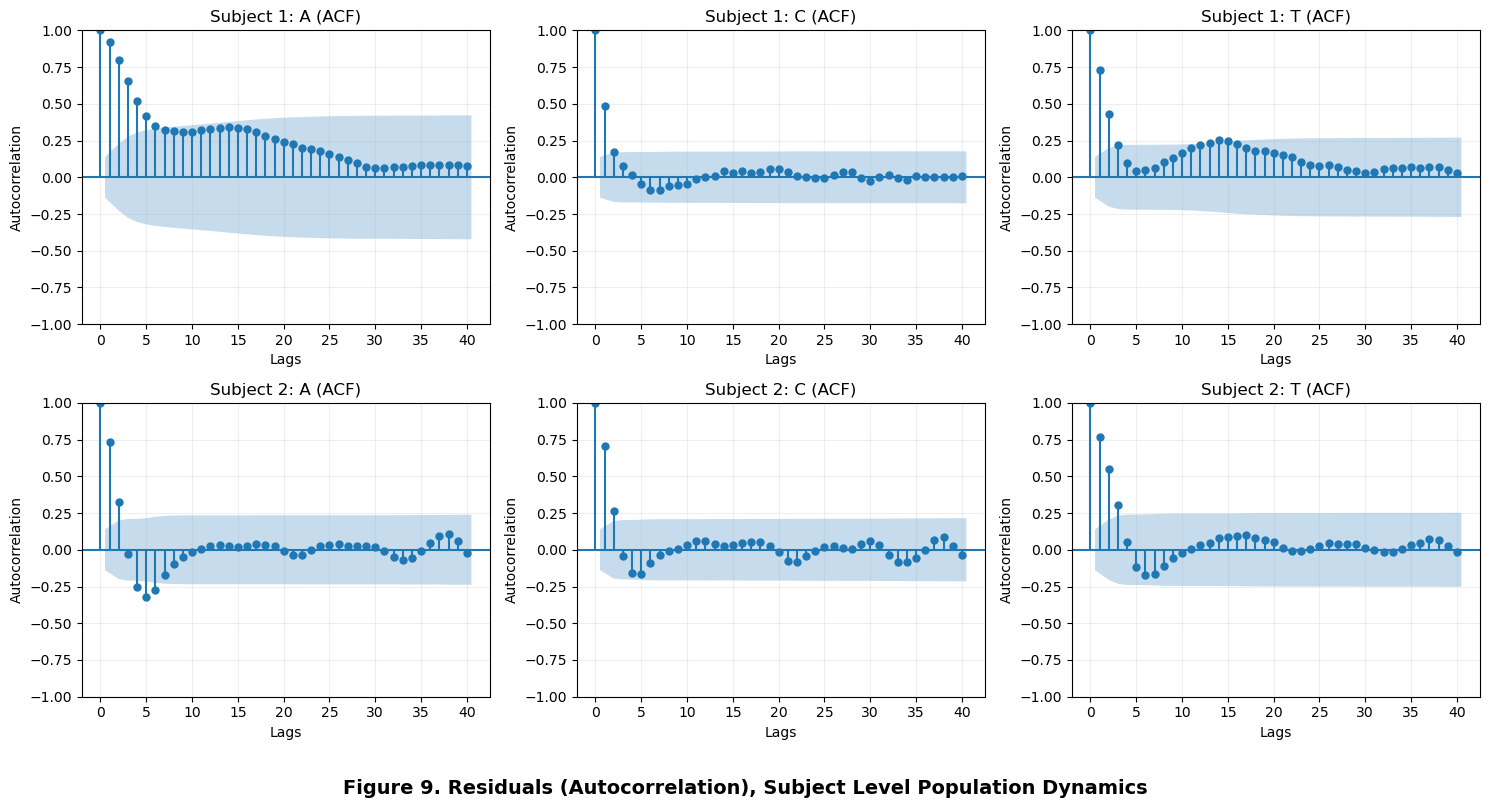

In [18]:
#---------------------------------------
# Residual Autocorrelation Analysis
#---------------------------------------

# 2 rows (one per subject), 3 columns (one per phase)
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for row, sub_name in enumerate(subjects):
    # 1. Retrieve and reshape residuals to (T_end_value, 3)
    rr = results[sub_name]['res_object'].fun
    res_matrix = rr.reshape((T_end_value, 3))
    
    for col in range(3):
        ax = axs[row, col]
        
        # 2. Plot ACF for the specific phase on the correct subplot axis
        # Suppress double-plotting by assigning to '_'
        _ = plot_acf(res_matrix[:, col], lags=40, ax=ax, title=f"{sub_name}: {labels[col]} (ACF)")
        
        # Formatting for readability
        ax.set_xlabel("Lags")
        ax.set_ylabel("Autocorrelation")
        ax.grid(alpha=0.2)

# Global title and adjustment
plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle("Figure 9. Residuals (Autocorrelation), Subject Level Population Dynamics", fontsize=14,
             fontweight='bold', y=0.02)
plt.show()


The residuals are not random; instead, they exhibit a clear exponentially decaying pattern. This indicates that the model fails to fully capture the underlying dynamics of the follicle cycle. The primary limitation arises from the linear SIR-type formulation, which assumes memoryless transitions between states. Such an assumption is not appropriate for biological systems like hair follicles, where the duration spent in each phase influences transition behavior.

Further evidence of model inadequacy is seen in the autocorrelation function (ACF), which shows that the residuals are not white noise and retain temporal structure. This confirms that important dynamics are missing from the model.

To address these issues, we introduced subcompartments within the anagen and telogen states. This modification allows the model to approximate non-exponential (non-memoryless) dwell-time distributions, thereby incorporating implicit memory into the system and improving its ability to capture the observed follicle dynamics.

In [19]:
def get_hair_cycle_steady_state(alpha, beta, gamma):
    """
    Calculates the steady-state proportions.
    alpha: Wake-up rate (T -> A)
    beta:  Termination rate (A -> C)
    gamma: Regression rate (C -> T)
    """
    # Calculate denominator: αβ + βγ + αγ
    denom = (alpha * beta) + (beta * gamma) + (alpha * gamma)
    
    # Calculate steady-state proportions
    a_star = (alpha * gamma) / denom
    c_star = (alpha * beta) / denom
    r_star = (beta * gamma) / denom
    
    return a_star, c_star, r_star

In [20]:
import pandas as pd

THRESHOLD = 2.5
steady_state_summary = []

for sub_name in subjects:
    res = results[sub_name]['res_object']
    
    
    alpha_val, beta_val, gamma_val = res.x  
    
    a, c, r = get_hair_cycle_steady_state(alpha_val, beta_val, gamma_val)
    ar_ratio = alpha_val / beta_val
    
    conclusion = "Non-Alopecic" if ar_ratio >= THRESHOLD else "Alopecic"
    
    steady_state_summary.append({
        'subject': sub_name,
        'Anagen': a,
        'Transient': c,
        'Resting': r,
        'A/R_Ratio': ar_ratio,
        "Conclusion": conclusion
    })



df_ss = pd.DataFrame(steady_state_summary)
print(f"Table 4: Engle's ARCH test:\n")
print(df_ss.to_markdown(index=False))

Table 4: Engle's ARCH test:

| subject   |   Anagen |   Transient |   Resting |   A/R_Ratio | Conclusion   |
|:----------|---------:|------------:|----------:|------------:|:-------------|
| Subject 1 | 0.68174  |    0.091681 |  0.226579 |     3.00884 | Non-Alopecic |
| Subject 2 | 0.460819 |    0.211868 |  0.327313 |     1.40788 | Alopecic     |


## III. Sub-compartmentalization

In [21]:
my_graph_final = """
graph TD
    %% The Top Corner
    C((C)) --> T1((T1))
    
    %% The Right Side
    T1 --> T2((T2))
    
    %% The Bottom Corner
    T2 --> A1((A1))
    
    %% The Left Side
    A1 --> A2((A2))
    
    %% Closing the loop (Back to Top)
    A2 --> C

    %% Styling
    style A1 fill:#f9f,stroke:#333,stroke-width:2px
    style A2 fill:#f9f,stroke:#333,stroke-width:2px
    style C fill:#fff,stroke:#333,stroke-width:2px
    style T1 fill:#bbf,stroke:#333,stroke-width:2px
    style T2 fill:#bbf,stroke:#333,stroke-width:2px
"""

draw_mermaid_centered(my_graph_final)
print_styled("Figure 10. A State Machine Representation of the Sub-compartmentalized Follicular Transition")



# # --- Saving Mermaid graph ---
# import requests

# def save_mermaid_image(graph_code, filename):
#     graphbytes = graph_code.encode("ascii")
#     base64_string = base64.b64encode(graphbytes).decode("ascii")
#     url = "https://mermaid.ink/img/" + base64_string
    
#     response = requests.get(url)
#     if response.status_code == 200:
#         with open(filename, 'wb') as f:
#             f.write(response.content)
#         print(f"Saved Mermaid diagram to {filename}")

# # Call this before or after your Matplotlib logic
# F1 = "."
# save_mermaid_image(my_graph_final, f"{F1}/02a_hair_cycle_diagram_final_TD.png")



In [22]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# --------------------------------------------------------------
# Subcompartment ODE System
# --------------------------------------------------------------
def follicle_subcomp_model(t, y, alpha, beta, gamma):
    """
    ODE System with 2 subcompartments for Telogen and Anagen.
    Transitions: C -> T1 -> T2 -> A1 -> A2 -> C
    """
    t1, t2, a1, a2, c = y
    
    # Rates: alpha (T), beta (A), gamma (C)
    dt1 = gamma * c - alpha * t1
    dt2 = alpha * t1 - alpha * t2
    da1 = alpha * t2 - beta * a1
    da2 = beta * a1 - beta * a2
    dc  = beta * a2 - gamma * c

    return [dt1, dt2, da1, da2, dc]

# --------------------------------------------------------------
# Initial State Helper
# --------------------------------------------------------------
def build_initial_state(A0, C0, T0):
    """
    Splits the observed initial population counts into sub-compartments.
    Assumes an even distribution (50/50) at t=0.
    Input:  A0, C0, T0 (Aggregated initial counts/proportions)
    Return: [T01, T02, A01, A02, C0] (Initial state vector for ODE)
    """
    return [T0/2, T0/2, A0/2, A0/2, C0]

# --------------------------------------------------------------
# Simulation Wrapper
# --------------------------------------------------------------
def solve_model(times, params, A0, C0, T0):
    """
    Runs the ODE solver and aggregates subcompartments back into 
    A, C, and T for comparison with observed data.
    """
    alpha, beta, gamma = params
    y0 = build_initial_state(A0, C0, T0)

    sol = solve_ivp(
        fun=lambda t, y: follicle_subcomp_model(t, y, alpha, beta, gamma),
        t_span=(times[0], times[-1]),
        y0=y0,
        t_eval=times,
        method="RK45",
        rtol=1e-7,
        atol=1e-9
    )

    t1, t2, a1, a2, c = sol.y
    
    # Aggregate sub-states back into the 3 main phases
    T_pred = t1 + t2 
    A_pred = a1 + a2
    C_pred = c

    return {
        "t1": t1, "t2": t2, "a1": a1, "a2": a2, "c": c,
        "A_pred": A_pred, "C_pred": C_pred, "T_pred": T_pred
    }

# --------------------------------------------------------------
# Residuals Function (for least_squares)
# --------------------------------------------------------------
def residuals_subcomp(params, times, A_obs, C_obs, T_obs):
    """
    Computes the difference between simulated data and ODE predictions.
    """
    # Extract initial conditions from the first index of observed data
    A0, C0, T0 = A_obs[0], C_obs[0], T_obs[0]

    # Run the model
    out = solve_model(times, params, A0, C0, T0)

    # Calculate errors across all three phases
    resA = out["A_pred"] - A_obs
    resC = out["C_pred"] - C_obs
    resT = out["T_pred"] - T_obs

    # Flatten into a 1D array for least_squares
    return np.concatenate([resA, resC, resT])


In [23]:
# Using same subjects definition and Initial guess for [alpha, beta, gamma]
p0 = [0.1, 0.1, 0.1]

for sub_name in subjects:
    # Retrieve the pre-processed normalized data
    norm_data = results[sub_name]['norm_data']
    a_obs, c_obs, t_obs = norm_data[:, 0], norm_data[:, 1], norm_data[:, 2]
    
    # 2. Run the nonlinear regression using the SUBCOMPARTMENT functions
    res = least_squares(
        residuals_subcomp,              # New residuals function
        p0,                             # Initial guess
        args=(t_data, a_obs, c_obs, t_obs),
        bounds=(0, np.inf),             # Rates must be positive
        method='trf',
#         verbose=2
    )
    
    # Store full object, optimized parameters, and the aggregated fitted curves
    results[sub_name]['subcomp_res_object'] = res 
    results[sub_name]['subcomp_params'] = res.x
    results[sub_name]['subcomp_out'] = solve_model(t_data, res.x, a_obs[0], c_obs[0], t_obs[0])
    print(f"\nFinished subcomp fitting {sub_name}. Params: {res.x}")


Finished subcomp fitting Subject 1. Params: [0.40151902 0.13398729 0.49751609]

Finished subcomp fitting Subject 2. Params: [0.16419706 0.11633268 0.12672657]


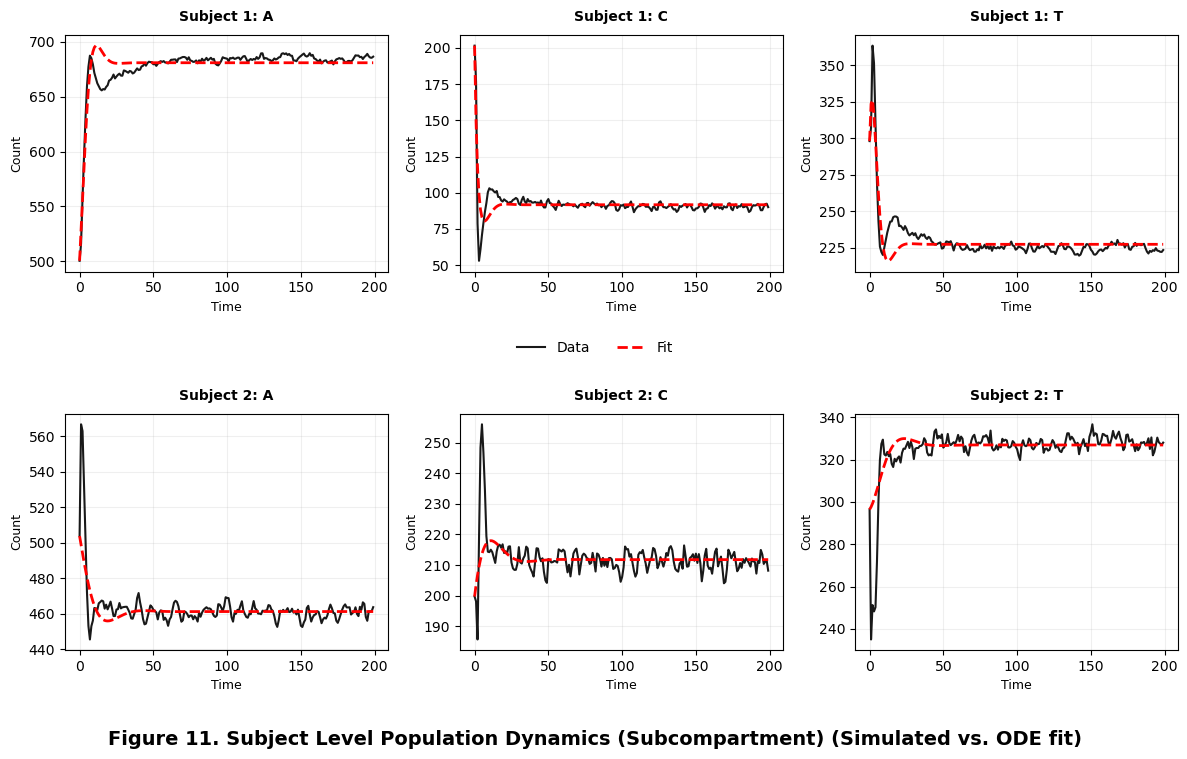

In [24]:
#---------------------------------------------------------------------------
# Plotting Multi-Subject Subcompartment Results
#---------------------------------------------------------------------------

fig, axs = plt.subplots(2, 3, figsize=(12, 7.5))

for row, sub_name in enumerate(subjects):
    orig = results[sub_name]['norm_data']
    out = results[sub_name]['subcomp_out'] 
    
    for col in range(3):
        ax = axs[row, col]
        
        # Plotting original data (NumPy array)
        l1, = ax.plot(t_data, orig[:, col] * N_value, '-', color='black', alpha=0.9, label='Data')
        
        # Plotting fitted data (from Dictionary using the key)
        current_key = f'{labels[col]}_pred'
        l2, = ax.plot(t_data, out[current_key] * N_value, '--', color='red', linewidth=2, label='Fit')
        
        ax.set_title(f"{sub_name}: {labels[col]}", fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.grid(alpha=0.2)

# Placement of legend
fig.legend(handles=[l1, l2], 
           loc='center', 
           bbox_to_anchor=(0.5, 0.53), 
           ncol=2, 
           frameon=True, 
           facecolor='white', 
           edgecolor='none')



# Global title and adjustment
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.subplots_adjust(hspace=0.6)
fig.suptitle("Figure 11. Subject Level Population Dynamics (Subcompartment) (Simulated vs. ODE fit)", fontsize=14,
             fontweight='bold', y=0.02)
plt.show()


Demonistarted better transient response.

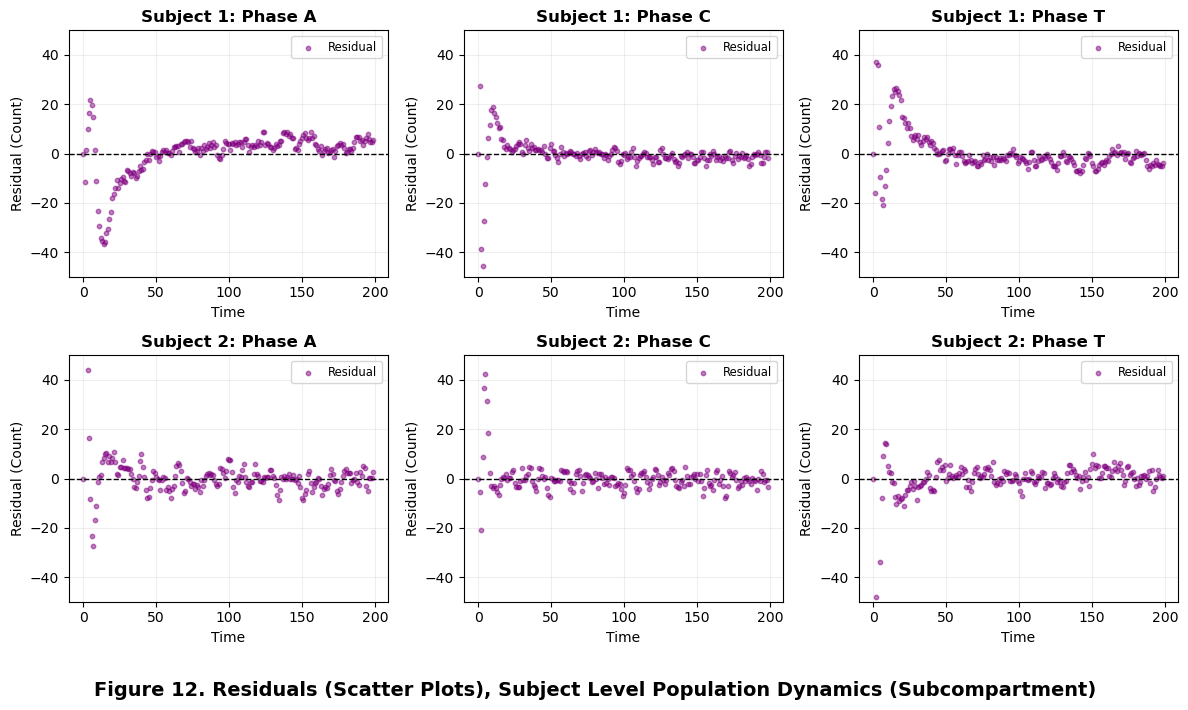

In [25]:
#-------------------------------------------------
# Residue scatter plots (Subcompartment results)
#-------------------------------------------------

fig, axs = plt.subplots(2, 3, figsize=(12, 7))

for row, sub_name in enumerate(subjects):
    # Retrieve data
    data = results[sub_name]['norm_data']
    out = results[sub_name]['subcomp_out']
    
    # Reconstruct the prediction array from the dictionary keys
    pred = np.column_stack([out[f'{k}_pred'] for k in labels_keys])
    
    # Calculate residuals
    res = (data - pred) * N_value
    
    for col in range(3):
        ax = axs[row, col]
        
        ax.scatter(t_data, res[:, col], s=10, alpha=0.5, color='purple', label='Residual')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        
        ax.set_title(f"{sub_name}: {labels_titles[col]}", fontweight='bold')
        ax.set_xlabel('Time')
        ax.set_ylabel('Residual (Count)')
        
        # Adjusting ylim
        ax.set_ylim(-50, 50) 
        
        ax.grid(alpha=0.2)
        ax.legend(loc='upper right', fontsize='small')


plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle("Figure 12. Residuals (Scatter Plots), Subject Level Population Dynamics (Subcompartment)", fontsize=14,
             fontweight='bold', y=0.02)
plt.show()

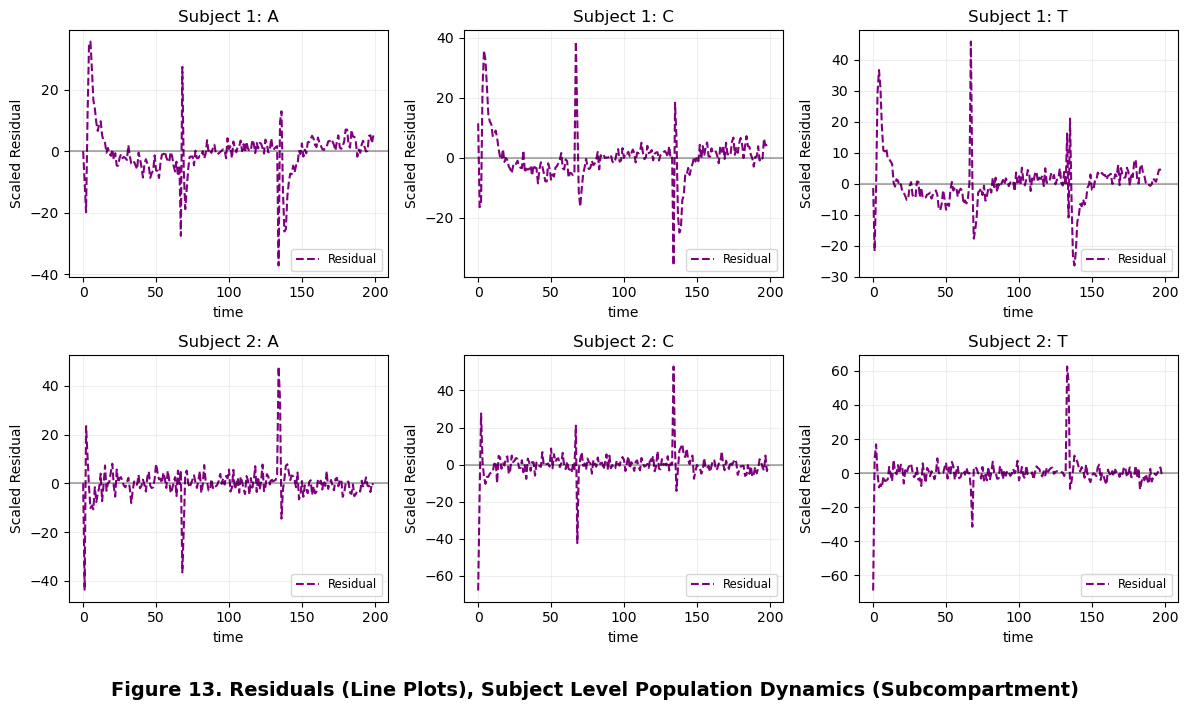

In [26]:
#-------------------------------------------------
# Multi-Subject Residue Line Plots
#-------------------------------------------------

fig, axs = plt.subplots(2, 3, figsize=(12, 7))

for row, sub_name in enumerate(subjects):
    # Retrieve residuals from the specific subject's result object
    # .fun contains the vector of residuals
    rr = results[sub_name]['subcomp_res_object'].fun
    
    # Reshape to (Number of time points, 3 phases)
    res_matrix = rr.reshape((len(t_data), 3))
    
    for col in range(3):
        ax = axs[row, col]
        
        # Plotting with scaling by N_value
        ax.plot(t_data, res_matrix[:, col] * N_value, '--', 
                linewidth=1.5, color='purple', label='Residual')
        
        # Zero line setting
        ax.axhline(0, color='black', linestyle='-', alpha=0.3)
        
        ax.set_title(f"{sub_name}: {labels[col]}")
        ax.set_xlabel('time')
        ax.set_ylabel('Scaled Residual')
        ax.legend(loc='lower right', fontsize='small')
        ax.grid(alpha=0.2)


plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle("Figure 13. Residuals (Line Plots), Subject Level Population Dynamics (Subcompartment)", fontsize=14,
             fontweight='bold', y=0.02)
plt.show()

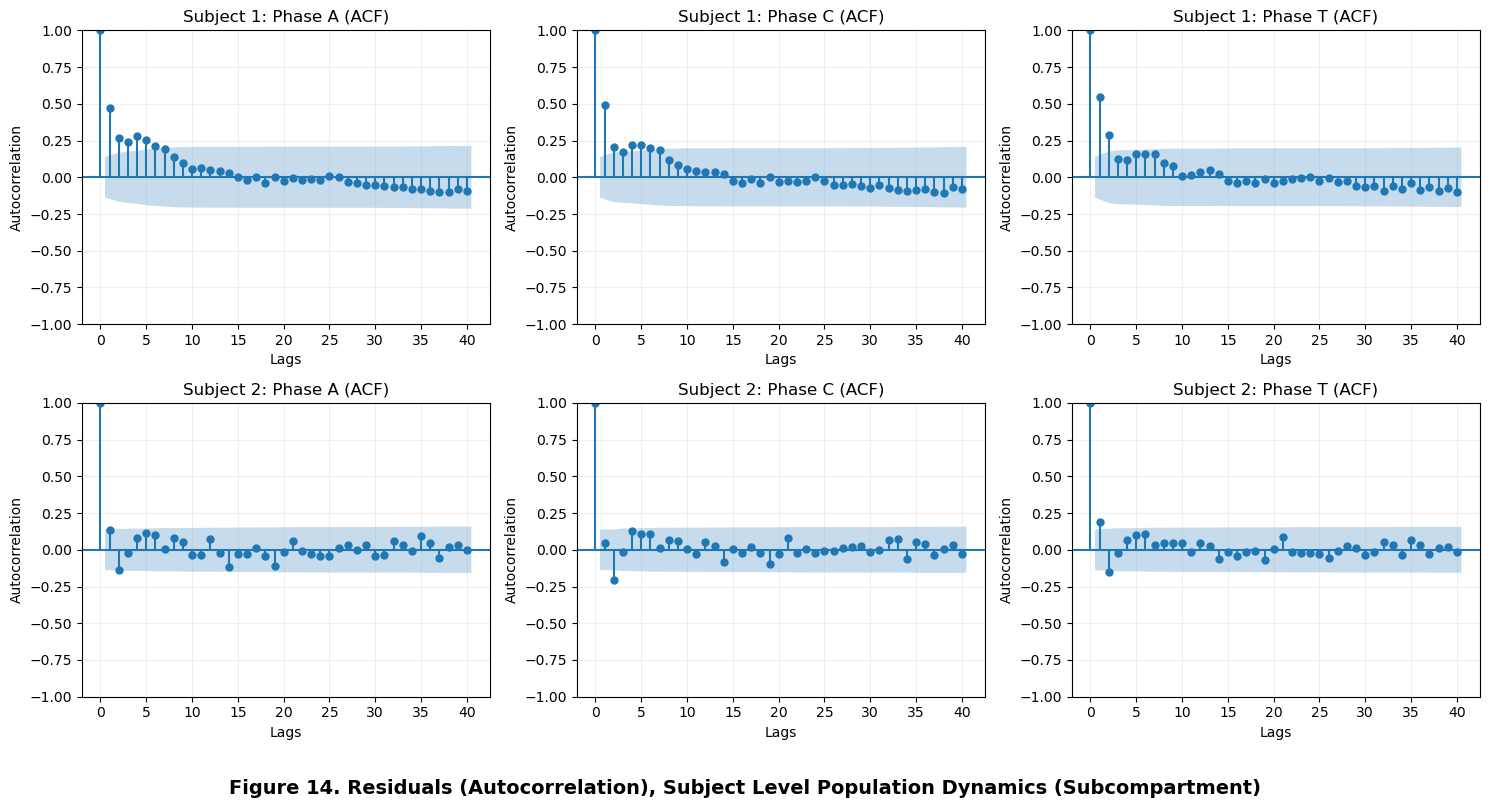

In [27]:
#----------------------------------------------------
# Residual Autocorrelation Analysis (Subcompartment)
#---------------------------------------------------


fig, axs = plt.subplots(2, 3, figsize=(15, 8))

for row, sub_name in enumerate(subjects):
    # Retrieve residuals 
    rr = results[sub_name]['subcomp_res_object'].fun
    
    # Reshape back to (Time, 3)
    res_matrix = rr.reshape((len(t_data), 3))
    
    for col in range(3):
        ax = axs[row, col]
        
        # Plot ACF for the specific phase
        _ = plot_acf(res_matrix[:, col], lags=40, ax=ax, 
                     title=f"{sub_name}: {phase_labels[col]} (ACF)")
        
        ax.set_xlabel("Lags")
        ax.set_ylabel("Autocorrelation")
        ax.grid(alpha=0.2)



plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle("Figure 14. Residuals (Autocorrelation), Subject Level Population Dynamics (Subcompartment)", fontsize=14,
             fontweight='bold', y=0.02)
plt.show()


The scatter plot doesn't show any pattern. The autoregression shows that the residue is white noise. So the model assumptions are ppropariate and the model is able to capture the dynamics of the follicle cycle. ???

## IV. Parameter Sensitivity and Hair Treatment 

In [28]:
for sub_name in subjects:
    res = results[sub_name]['subcomp_res_object']
    
    print(f"--- Summary for {sub_name} ---")
    print(f"Termination: {res.message}")
    print(f"Function evaluations: {res.nfev}")
    print(f"Initial cost: {res.cost:.4e}") # Note: res.cost is the final cost
    print(f"Optimality: {res.optimality:.2e}")
    print(f"Optimized Params: {res.x}")
    print("-" * 30)


--- Summary for Subject 1 ---
Termination: `xtol` termination condition is satisfied.
Function evaluations: 34
Initial cost: 1.8219e-02
Optimality: 3.07e-03
Optimized Params: [0.40151902 0.13398729 0.49751609]
------------------------------
--- Summary for Subject 2 ---
Termination: `ftol` termination condition is satisfied.
Function evaluations: 12
Initial cost: 1.9456e-02
Optimality: 6.49e-06
Optimized Params: [0.16419706 0.11633268 0.12672657]
------------------------------


In [29]:

optimized_params_data = []
headers = ["Subject", "Alpha (α)", "Gamma (γ)"]

for sub_name in subjects:
    res = results[sub_name]['subcomp_res_object']
    alpha, beta, gamma = res.x
    
    optimized_params_data.append([
        sub_name, 
        f"{alpha:.4f}", 
        f"{gamma:.4f}"
    ])

print(f"\nTable 5: Optimized Transition Parameters (α and γ)")
print(tabulate(optimized_params_data, headers=headers, tablefmt="grid"))



Table 5: Optimized Transition Parameters (α and γ)
+-----------+-------------+-------------+
| Subject   |   Alpha (α) |   Gamma (γ) |
+===========+=============+=============+
| Subject 1 |      0.4015 |      0.4975 |
+-----------+-------------+-------------+
| Subject 2 |      0.1642 |      0.1267 |
+-----------+-------------+-------------+


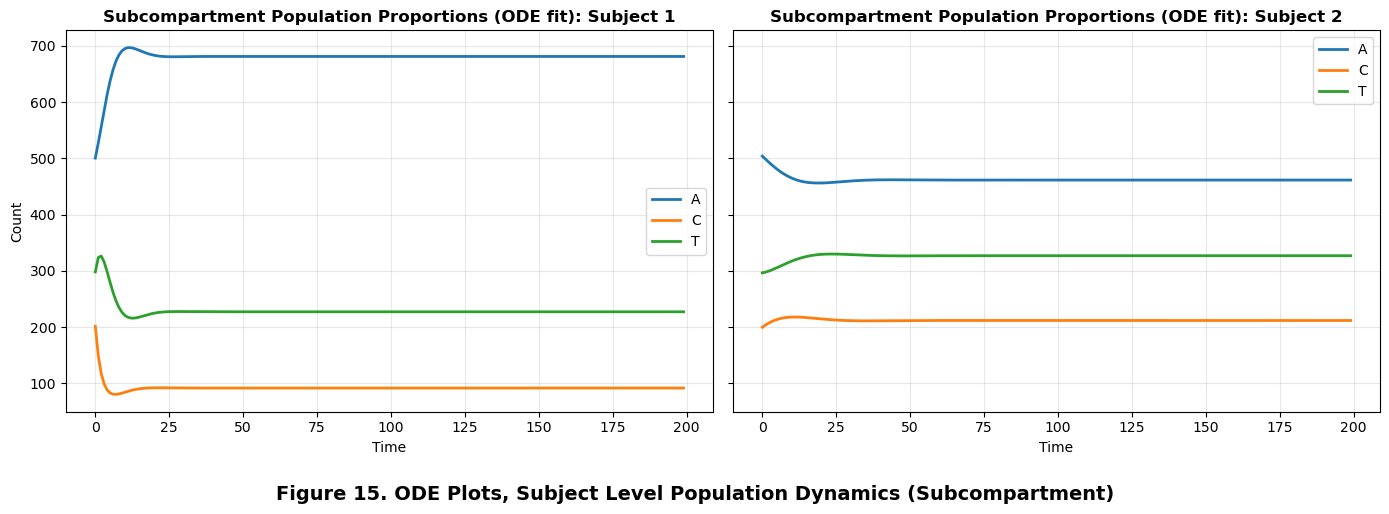

In [30]:
#-------------------------------------------------------------
# ODE fit plots for Hair Cycle Data (subcompartmentalization)
#-------------------------------------------------------------

labels = ['A', 'C', 'T']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, sub_name in enumerate(subjects):
    ax = axs[i]
    out = results[sub_name]['subcomp_out']
    
    # Plot all 3 phases (A, C, T) on the same subplot
    for j in range(3):
        key = f'{labels[j]}_pred'
        ax.plot(t_data, out[key] * N_value, label=labels[j], color=colors[j], linewidth=2)
    
    ax.set_title(f"Subcompartment Population Proportions (ODE fit): {sub_name}", fontweight='bold')
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel("Count")
    
    ax.grid(alpha=0.3)
    ax.legend()



plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle("Figure 15. ODE Plots, Subject Level Population Dynamics (Subcompartment)", fontsize=14,
             fontweight='bold', y=0.02)
plt.show()


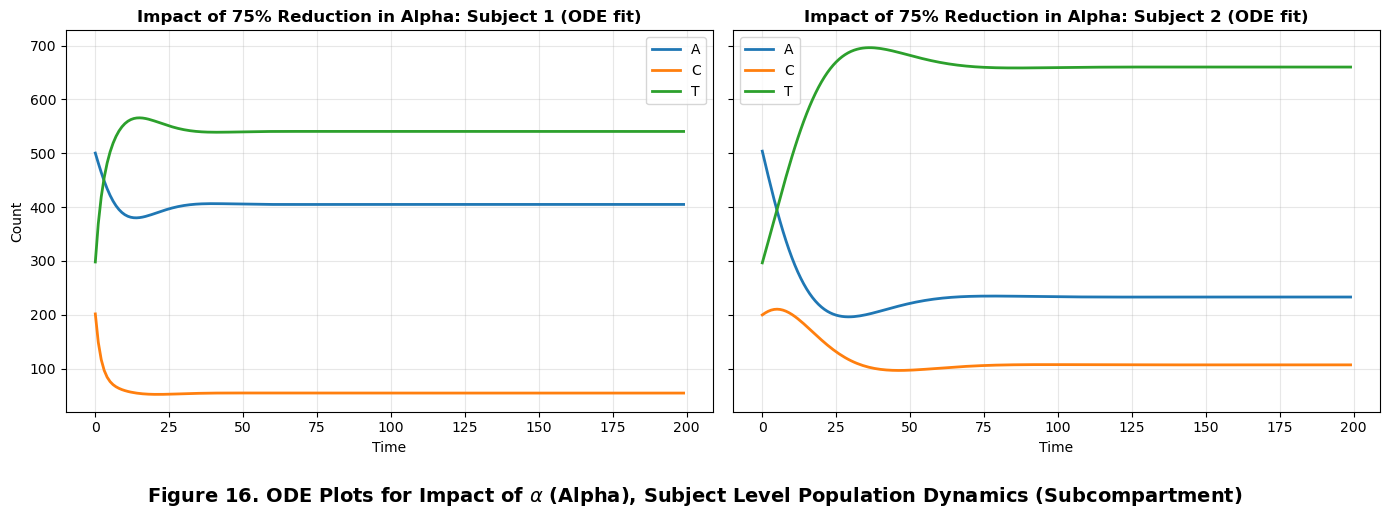

In [31]:
#-------------------------------------------------------------
# Impact of reduction in alpha (subcompartmentalization)
# Transition: A -> C)
#-------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, sub_name in enumerate(subjects):
    ax = axs[i]
    
    # Retrieve original optimized parameters and initial conditions
    theta = results[sub_name]['subcomp_params'].copy()
    norm_data = results[sub_name]['norm_data']
    a0, c0, t0 = norm_data[0]
    
    # Apply the simulation change: reduce alpha (index 0) by half
    theta[0] = theta[0] / 4
    
    # Re-solve the model with the modified parameters
    sim_out = solve_model(t_data, theta, a0, c0, t0)
    
    # Plot all three phases
    for j in range(3):
        key = f'{labels[j]}_pred'
        ax.plot(t_data, sim_out[key] * N_value, label=labels[j], linewidth=2)
    
    ax.set_title(f"Impact of 75% Reduction in Alpha: {sub_name} (ODE fit)", fontweight='bold')
    ax.set_xlabel("Time")
    if i == 0: ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    ax.legend()


plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle(r"Figure 16. ODE Plots for Impact of $\alpha$ (Alpha), Subject Level Population Dynamics (Subcompartment)", 
             fontsize=14, fontweight='bold', y=0.02)

plt.show()

We observe that when alpha is reduced—corresponding to an increased Wnt activation threshold—the transition into the anagen phase decreases. As a result, the proportion of follicles in anagen becomes lower than that in catagen. This shift indicates reduced hair growth activity and suggests a higher susceptibility to hair loss (baldness). Results show that the impact is much higher in Subject 2.

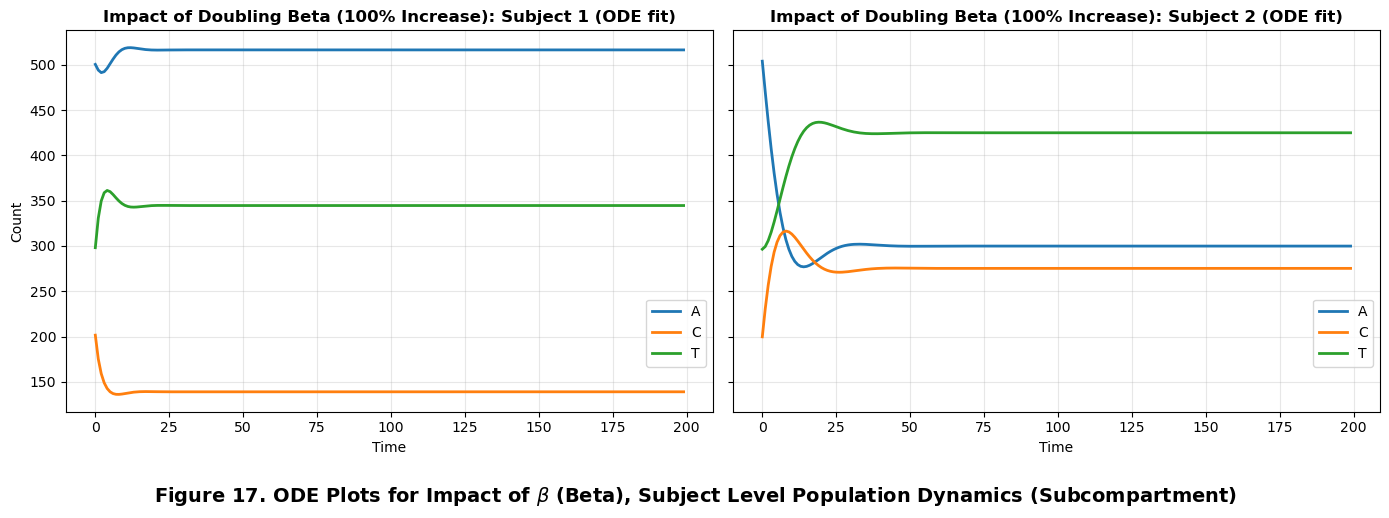

In [32]:
#-------------------------------------------------------------
# Impact of doubling Beta (subcompartmentalization)
# Transition: C -> T)
#-------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, sub_name in enumerate(subjects):
    ax = axs[i]
    
    # Retrieve parameters
    theta = results[sub_name]['subcomp_params'].copy()
    norm_data = results[sub_name]['norm_data']
    a0, c0, t0 = norm_data[0]
    
    # Doubling Beta (Transition C -> T)
    theta[1] = theta[1] * 2
    
    sim_out = solve_model(t_data, theta, a0, c0, t0)
    
    for j in range(3):
        key = f'{labels[j]}_pred'
        ax.plot(t_data, sim_out[key] * N_value, label=labels[j], linewidth=2)
    
    # Title
    ax.set_title(f"Impact of Doubling Beta (100% Increase): {sub_name} (ODE fit)", fontweight='bold')
    ax.set_xlabel("Time")
    if i == 0: ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    
    ax.legend(loc='lower right', bbox_to_anchor=(1, 0.1))




    
plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle(r"Figure 17. ODE Plots for Impact of $\beta$ (Beta), Subject Level Population Dynamics (Subcompartment)", 
             fontsize=14, fontweight='bold', y=0.02)

plt.show()


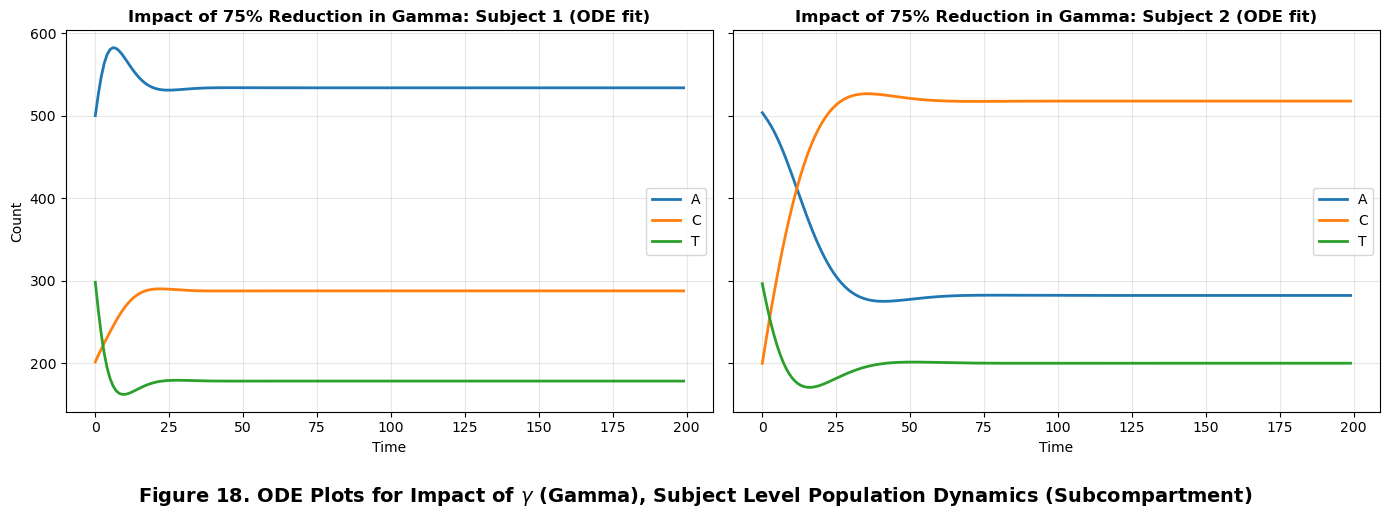

In [33]:
#-------------------------------------------------------------
# Impact of 75% Reduction in Gamma (subcompartmentalization)
# Transition: T -> A
#-------------------------------------------------------------

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, sub_name in enumerate(subjects):
    ax = axs[i]
    
    # Retrieve parameters
    theta = results[sub_name]['subcomp_params'].copy()
    norm_data = results[sub_name]['norm_data']
    a0, c0, t0 = norm_data[0]
    
    # Reduce Gamma (Transition T -> A) by 75%
    theta[2] = theta[2] / 4
    
    # Re-solve the model
    sim_out = solve_model(t_data, theta, a0, c0, t0)
    
    # Plot all three phases
    for j in range(3):
        key = f'{labels[j]}_pred'
        ax.plot(t_data, sim_out[key] * N_value, label=labels[j], linewidth=2)
    
    # Title
    ax.set_title(f"Impact of 75% Reduction in Gamma: {sub_name} (ODE fit)", fontweight='bold')
    ax.set_xlabel("Time")
    if i == 0: ax.set_ylabel("Count")
    ax.grid(alpha=0.3)
    ax.legend(loc='center right')


plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.suptitle(r"Figure 18. ODE Plots for Impact of $\gamma$ (Gamma), Subject Level Population Dynamics (Subcompartment)", 
             fontsize=14, fontweight='bold', y=0.02)

plt.show()


In [34]:
import pandas as pd

THRESHOLD = 2.5
steady_state_summary = []

for sub_name in subjects:
    res = results[sub_name]['subcomp_res_object']
    
    
    alpha_val, beta_val, gamma_val = res.x  
    
    a, c, r = get_hair_cycle_steady_state(alpha_val, beta_val, gamma_val)
    ar_ratio = alpha_val / beta_val
    
    conclusion = "Non-Alopecic" if ar_ratio >= THRESHOLD else "Alopecic"
    
    steady_state_summary.append({
        'subject': sub_name,
        'Anagen': a,
        'Transient': c,
        'Resting': r,
        'A/R_Ratio': ar_ratio,
        "Conclusion": conclusion
    })



df_ss = pd.DataFrame(steady_state_summary)
print(f"\nTable 6: A/R Ratio\n")
print(df_ss.to_markdown(index=False))


Table 6: A/R Ratio

| subject   |   Anagen |   Transient |   Resting |   A/R_Ratio | Conclusion   |
|:----------|---------:|------------:|----------:|------------:|:-------------|
| Subject 1 | 0.623825 |    0.168004 |  0.208171 |     2.99669 | Non-Alopecic |
| Subject 2 | 0.380738 |    0.349511 |  0.269751 |     1.41144 | Alopecic     |
